In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import requests
from PIL import Image
import io

In [2]:
# Define dimensions
rows = 100
cols = 100
ten_cols = 50

# Create a matrix of 10s for the first 50 columns
part_tens = np.full((rows, ten_cols), 10)

# Create a matrix of 0s for the remaining columns
part_zeros = np.zeros((rows, cols - ten_cols))

# Concatenate them horizontally to form the final matrix
matrix = np.hstack((part_tens, part_zeros))

print(matrix)

[[10. 10. 10. ...  0.  0.  0.]
 [10. 10. 10. ...  0.  0.  0.]
 [10. 10. 10. ...  0.  0.  0.]
 ...
 [10. 10. 10. ...  0.  0.  0.]
 [10. 10. 10. ...  0.  0.  0.]
 [10. 10. 10. ...  0.  0.  0.]]


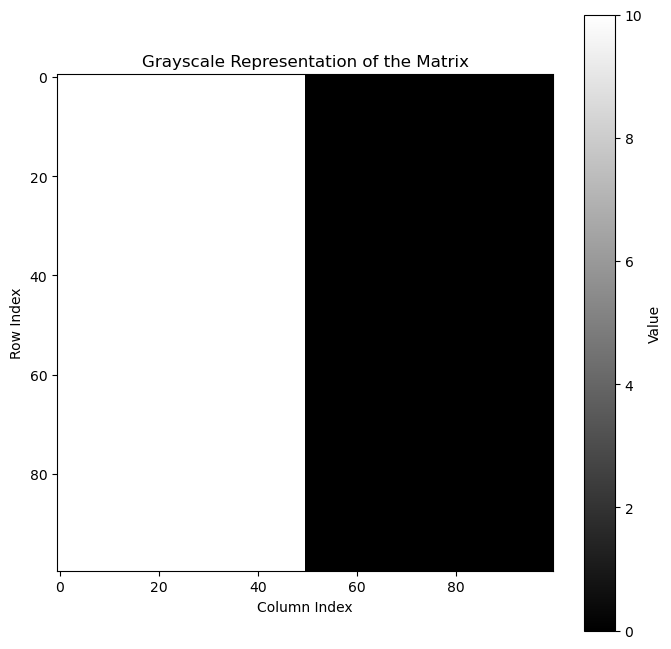

In [3]:
# Display the matrix as a grayscale image
plt.figure(figsize=(8, 8))
plt.imshow(matrix, cmap='gray', vmin=0, vmax=10)
plt.colorbar(label='Value')
plt.title('Grayscale Representation of the Matrix')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.show()

In [4]:
# define the filter to detect vertical edges
vertical_edge_filter = np.array([[1, 0, -1],
                                 [1, 0, -1],
                                 [1, 0, -1]])

print(vertical_edge_filter)

[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]


In [5]:
# Define your two matrices as PyTorch tensors
# Input matrix: (Batch_size, Channels, Height, Width)
# For a single grayscale image, batch_size=1, channels=1
input_matrix = torch.tensor(matrix, dtype=torch.float32).unsqueeze(0).unsqueeze(0) # Add batch and channel dimensions

# Kernel matrix: (Out_channels, In_channels, Kernel_height, Kernel_width)
# For a single filter, out_channels=1, in_channels=1
kernel_matrix = torch.tensor(vertical_edge_filter, dtype=torch.float32).unsqueeze(0).unsqueeze(0) # Add out_channel and in_channel dimensions

# print(f"Input matrix shape: {input_matrix.shape}")
# print(f"Kernel matrix shape: {kernel_matrix.shape}")

# Perform 2D convolution
# stride=1 (default if not specified)
# padding=0 (default if not specified)
output_matrix = F.conv2d(input_matrix, kernel_matrix)
output_matrix = output_matrix.squeeze() # Remove batch and channel dimensions

print(f"\nOutput matrix shape: {output_matrix.shape}")
print("Output matrix values:")
print(output_matrix)


Output matrix shape: torch.Size([98, 98])
Output matrix values:
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])


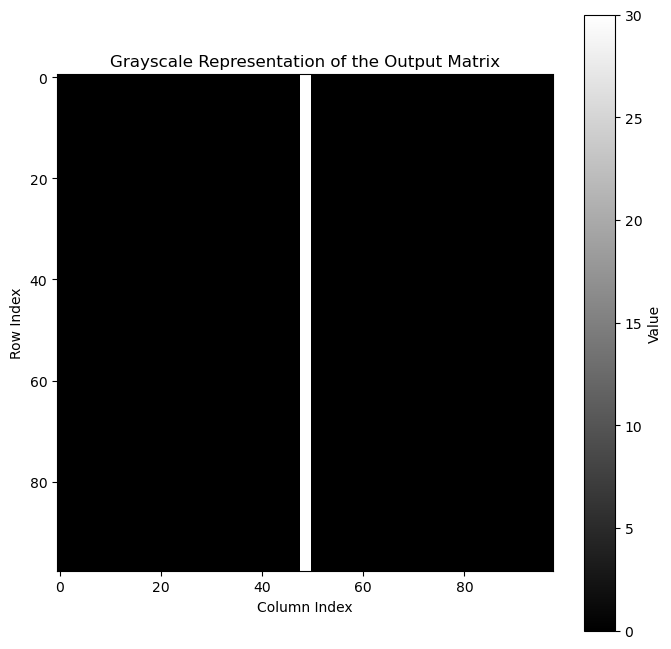

In [6]:
# display the matrix as a grayscale image
plt.figure(figsize=(8, 8))
plt.imshow(output_matrix, cmap='gray', vmin=0, vmax=30)
plt.colorbar(label='Value')
plt.title('Grayscale Representation of the Output Matrix')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.show()

Can you find the vertical edges in the following grayscale photo?


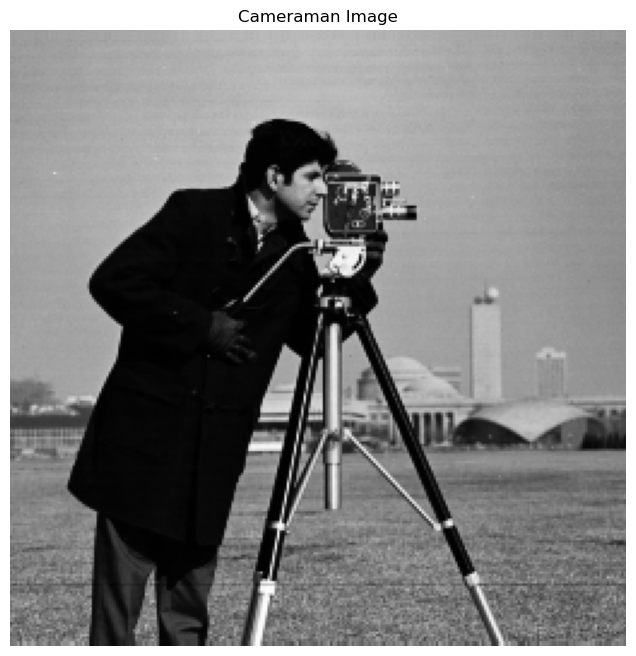

In [7]:
image_url = 'https://github.com/benjaminmlucas/MAT499/raw/1a7f1397cfb5b3990357496d4dfa2ea152732727/module_3/the_cameraman.png'
response = requests.get(image_url)
response.raise_for_status() # Raise an exception for bad status codes

# Open the image using PIL
image_bytes = io.BytesIO(response.content)
cameraman_pil = Image.open(image_bytes)

# Display the PIL image
plt.figure(figsize=(8, 8))
plt.imshow(cameraman_pil, cmap='gray')
plt.title('Cameraman Image')
plt.axis('off')
plt.show()

In [10]:
# Convert the PIL Image to a NumPy array
cameraman = np.array(cameraman_pil)

In [15]:
# Define your two matrices as PyTorch tensors
# Input matrix: (Batch_size, Channels, Height, Width)
# For a single grayscale image, batch_size=1, channels=1
input_matrix = torch.tensor(cameraman, dtype=torch.float32).unsqueeze(0).unsqueeze(0) # Add batch and channel dimensions

# Kernel matrix: (Out_channels, In_channels, Kernel_height, Kernel_width)
# For a single filter, out_channels=1, in_channels=1
kernel_matrix = torch.tensor(vertical_edge_filter, dtype=torch.float32).unsqueeze(0).unsqueeze(0) # Add out_channel and in_channel dimensions

print(f"Input matrix shape: {input_matrix.shape}")
print(f"Kernel matrix shape: {kernel_matrix.shape}")

# Perform 2D convolution
# stride=1 (default if not specified)
# padding=0 (default if not specified)
output_matrix = F.conv2d(input_matrix, kernel_matrix)
output_matrix = output_matrix.squeeze() # Remove batch and channel dimensions

print(f"\nOutput matrix shape: {output_matrix.shape}")
print("Output matrix values:")
print(output_matrix)

Input matrix shape: torch.Size([1, 1, 256, 256])
Kernel matrix shape: torch.Size([1, 1, 3, 3])

Output matrix shape: torch.Size([254, 254])
Output matrix values:
tensor([[ -1.,   4.,   0.,  ...,   7.,   2.,  -1.],
        [  4.,  -4.,   0.,  ...,   5.,   1.,   1.],
        [  2.,  -6.,  -4.,  ...,   1.,   2.,   2.],
        ...,
        [-18.,  53.,  71.,  ..., -36., -34.,  29.],
        [-15.,  -5.,  99.,  ..., -20., -20.,  53.],
        [-27., -39.,  90.,  ..., -10., -12.,  61.]])


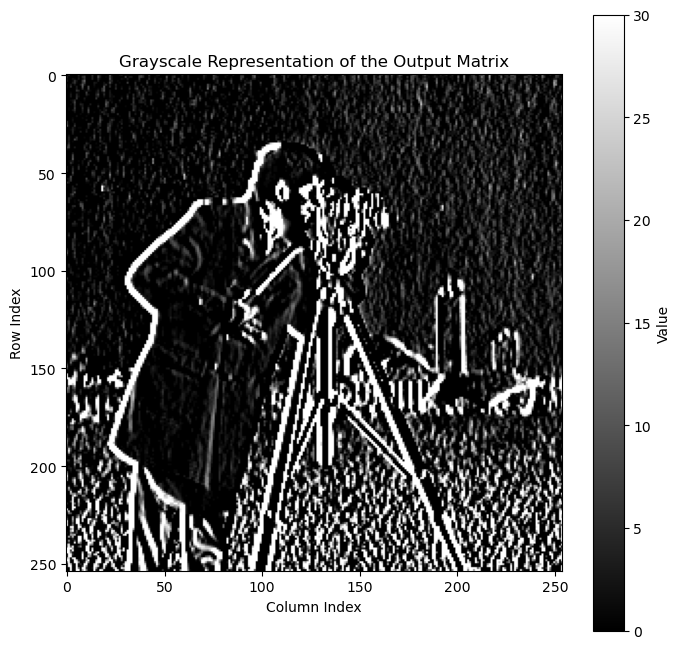

In [14]:
# display the matrix as a grayscale image
plt.figure(figsize=(8, 8))
plt.imshow(output_matrix, cmap='gray', vmin=0, vmax=30)
plt.colorbar(label='Value')
plt.title('Grayscale Representation of the Output Matrix')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.show()